# Redução de Dimensionalidade com PCA e t-SNE

Este notebook foi criado para introduzir, de forma **visual e intuitiva**, o tema de **redução de dimensionalidade**.

A ideia central é simples:

- cada exemplo de dados é descrito por várias **features**;
- o número de features está diretamente relacionado à **dimensionalidade** do problema;
- técnicas de redução de dimensionalidade tentam representar os mesmos dados em menos dimensões, preservando a estrutura mais importante.

Aqui vamos explorar duas técnicas muito usadas no `scikit-learn`:

- **PCA** (*Principal Component Analysis*)
- **t-SNE** (*t-distributed Stochastic Neighbor Embedding*)

> Neste notebook, o foco será a **intuição de uso**, não a matemática detalhada.

## Objetivos do notebook

Ao final, você deverá ser capaz de:

- entender por que o número de features está ligado à dimensionalidade;
- compreender por que reduzir dimensionalidade pode ser útil;
- usar `PCA` e `TSNE` com `scikit-learn`;
- interpretar os principais parâmetros dessas técnicas;
- visualizar diferenças práticas entre PCA e t-SNE.

## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, load_digits, make_moons
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = True
np.random.seed(42)

## 2. O que é dimensionalidade?

Em aprendizado de máquina, cada amostra normalmente é representada por um vetor de atributos:

- se uma amostra tem **2 features**, ela pode ser vista como um ponto em **2 dimensões**;
- se tem **3 features**, ela vive em **3 dimensões**;
- se tem **100 features**, ela vive em **100 dimensões**.

Ou seja:

> **número de features = dimensionalidade da representação dos dados**

In [2]:
X_exemplo = np.array([
    [1.2, 3.4, 0.7, 8.1],
    [0.9, 3.8, 0.5, 7.9],
    [1.4, 3.1, 0.8, 8.3],
])

print("Shape de X_exemplo:", X_exemplo.shape)
print("Número de amostras:", X_exemplo.shape[0])
print("Número de features:", X_exemplo.shape[1])

Shape de X_exemplo: (3, 4)
Número de amostras: 3
Número de features: 4


### Interpretação

No exemplo acima:

- temos **3 amostras**;
- cada amostra possui **4 features**;
- portanto, os dados estão representados em um espaço de **4 dimensões**.

O problema é que não conseguimos visualizar diretamente espaços com 4, 10, 50 ou 100 dimensões.

## 3. Por que reduzir dimensionalidade?

Redução de dimensionalidade é útil porque:

- muitas features podem carregar informação redundante;
- algumas podem conter muito ruído;
- dados com muitas dimensões são difíceis de visualizar;
- em alguns casos, trabalhar com menos dimensões simplifica a análise.

Em termos intuitivos, é como tentar fazer um **resumo dos dados**, mantendo o que é mais importante.

## 4. Exemplo visual simples: quando conseguimos visualizar diretamente

Se um dataset tem apenas 2 features, podemos representar cada amostra em um plano.

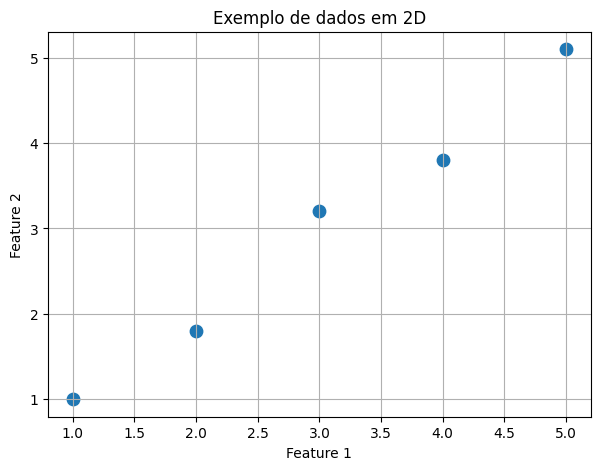

In [3]:
X_2d = np.array([
    [1, 1],
    [2, 1.8],
    [3, 3.2],
    [4, 3.8],
    [5, 5.1]
])

plt.scatter(X_2d[:, 0], X_2d[:, 1], s=80)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Exemplo de dados em 2D")
plt.show()

Agora pense em um dataset com 4, 20 ou 64 features.  
Nesse caso, já não conseguimos “enxergar” diretamente o espaço original dos dados.

## 5. Dataset Iris: um primeiro exemplo real

O dataset Iris é um clássico do aprendizado de máquina.

Cada flor é representada por **4 features**:

- comprimento da sépala
- largura da sépala
- comprimento da pétala
- largura da pétala

Portanto, cada flor vive em um espaço de **4 dimensões**.

In [4]:
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

print("Shape de X_iris:", X_iris.shape)
print("Features:", iris.feature_names)
print("Classes:", iris.target_names)

Shape de X_iris: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']


Mesmo com apenas 4 features, já não conseguimos visualizar diretamente a distribuição completa dos dados sem algum tipo de projeção ou redução de dimensionalidade.

## 6. PCA: intuição

A ideia intuitiva do **PCA** é:

> encontrar novos eixos que resumam os dados da melhor forma possível.

Em vez de usar os eixos originais das features, o PCA cria **novas direções** que tentam capturar a maior parte da variação dos dados.

De forma simples:

- o primeiro componente principal tenta capturar a maior variação possível;
- o segundo captura a maior variação restante;
- e assim por diante.

### Intuição geométrica

Imagine uma nuvem de pontos inclinada.  
O PCA tenta encontrar o eixo “mais natural” dessa nuvem.

Isso faz com que ele seja muito útil para:

- compressão;
- visualização;
- remoção de redundância entre features.

## 7. Exemplo 2D de PCA: reduzindo de 2 dimensões para 1

Vamos criar um conjunto de pontos 2D onde as duas features são bem correlacionadas.

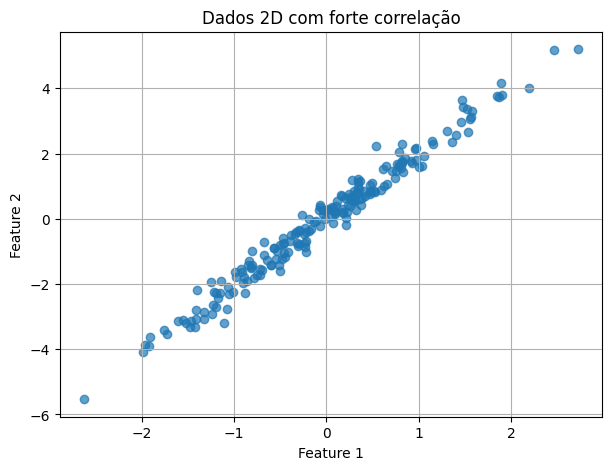

In [5]:
x = np.random.randn(200)
y = 2*x + 0.3*np.random.randn(200)
X_corr = np.column_stack([x, y])

plt.scatter(X_corr[:, 0], X_corr[:, 1], alpha=0.7)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Dados 2D com forte correlação")
plt.show()

Visualmente, os pontos formam uma “nuvem inclinada”.  
Isso sugere que talvez possamos resumir bem os dados usando apenas uma direção principal.

In [6]:
pca_1d = PCA(n_components=1)
X_corr_pca = pca_1d.fit_transform(X_corr)

print("Shape original:", X_corr.shape)
print("Shape após PCA:", X_corr_pca.shape)
print("Variância explicada:", pca_1d.explained_variance_ratio_)

Shape original: (200, 2)
Shape após PCA: (200, 1)
Variância explicada: [0.99631085]


### O que significa `n_components=1`?

Esse parâmetro define quantas dimensões queremos manter.

Aqui:

- os dados originais tinham **2 features**;
- após o PCA, passam a ter **1 componente principal**.

Ou seja, resumimos os dados de 2D para 1D.

### Parâmetros importantes do PCA

#### `n_components`
Número de componentes principais que queremos manter.

Exemplos:
- `n_components=2`: reduz para 2 dimensões;
- `n_components=1`: reduz para 1 dimensão.

#### `explained_variance_ratio_`
Não é parâmetro, mas um atributo muito importante após o ajuste.

Ele informa quanto da variabilidade dos dados foi preservada em cada componente.

Se o primeiro componente explica, por exemplo, 95% da variância, isso sugere que 1 dimensão já resume muito bem os dados.

#### `random_state`
Nem sempre é necessário em PCA, mas pode ser útil em alguns cenários de reprodutibilidade.

#### `whiten`
Transforma a escala das componentes. Para uma introdução, normalmente não é necessário usar.

## 8. Reconstrução aproximada com PCA

Uma forma muito boa de entender o PCA é:

1. reduzir os dados para menos dimensões;
2. depois reconstruí-los aproximadamente.

Se a reconstrução continuar parecida com os dados originais, isso sugere que pouca informação foi perdida.

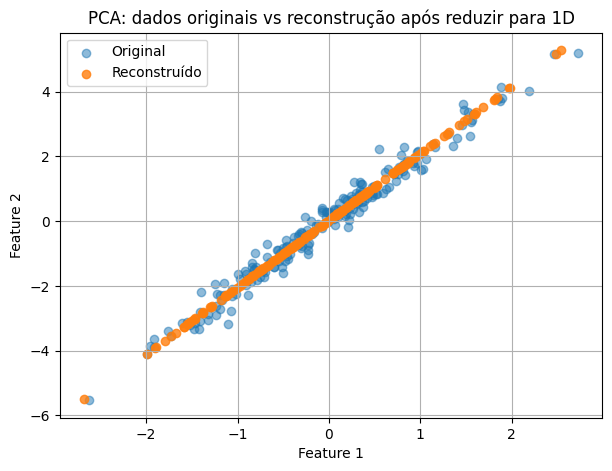

In [7]:
X_corr_reconstructed = pca_1d.inverse_transform(X_corr_pca)

plt.scatter(X_corr[:, 0], X_corr[:, 1], alpha=0.5, label="Original")
plt.scatter(X_corr_reconstructed[:, 0], X_corr_reconstructed[:, 1], alpha=0.8, label="Reconstruído")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("PCA: dados originais vs reconstrução após reduzir para 1D")
plt.legend()
plt.show()

Perceba que a reconstrução não é idêntica ao original, mas preserva a estrutura principal da nuvem de pontos.

Essa é uma das intuições mais importantes do PCA:

> ele comprime os dados tentando preservar o máximo possível da informação global.

## 9. PCA no dataset Iris

Agora vamos usar PCA para projetar o Iris, que está em 4D, em um espaço 2D.

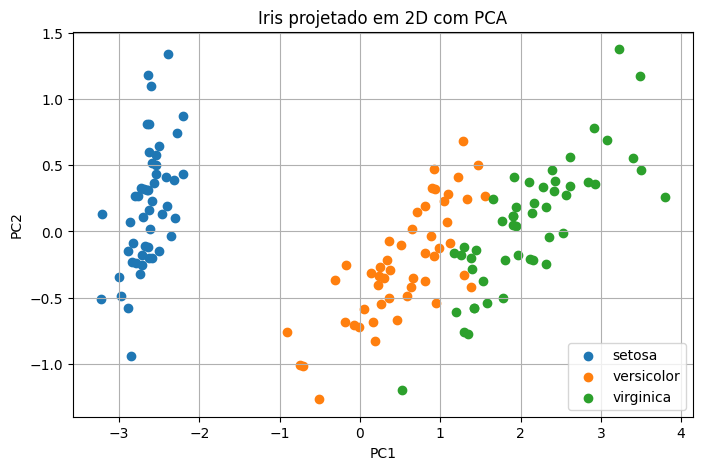

Variância explicada por componente: [0.92461872 0.05306648]
Variância acumulada: [0.92461872 0.97768521]


In [8]:
pca_iris = PCA(n_components=2)
X_iris_pca = pca_iris.fit_transform(X_iris)

plt.figure(figsize=(8, 5))
for classe, nome in enumerate(iris.target_names):
    plt.scatter(
        X_iris_pca[y_iris == classe, 0],
        X_iris_pca[y_iris == classe, 1],
        label=nome
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Iris projetado em 2D com PCA")
plt.legend()
plt.show()

print("Variância explicada por componente:", pca_iris.explained_variance_ratio_)
print("Variância acumulada:", np.cumsum(pca_iris.explained_variance_ratio_))

### Interpretação

Aqui:

- os dados originais tinham **4 features**;
- com PCA, passamos a representar cada amostra em **2 componentes principais**;
- agora conseguimos visualizar a distribuição em um gráfico 2D.

Além disso, a **variância acumulada** ajuda a entender quanta informação foi preservada.

## 9.1 Escolhendo o número certo de dimensões

Ao invés de escolher de forma mágica o número de dimensões para a redução, é mais simples escolher um número que gere uma soma de variancias maior que um determinado trashold. Por exemplo, se quisermos que avariancia acumulada no dataset de IRis seja 0.98, podemos fazer o seguinte:

Shape após PCA: (150, 3)


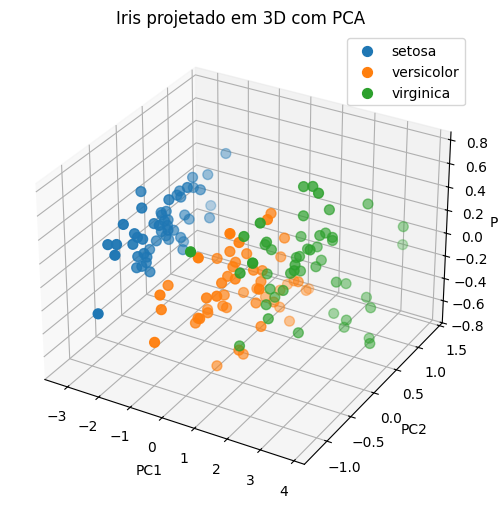

Variância explicada por componente: [0.92461872 0.05306648 0.01710261]
Variância acumulada: [0.92461872 0.97768521 0.99478782]


In [25]:
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # necessário para projeção 3D
import numpy as np

# Dados
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# PCA mantendo 98% da variância
pca_iris = PCA(n_components=0.98)
X_iris_pca = pca_iris.fit_transform(X_iris)

print("Shape após PCA:", X_iris_pca.shape)

# Plot 3D
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')

for classe, nome in enumerate(iris.target_names):
    ax.scatter(
        X_iris_pca[y_iris == classe, 0],
        X_iris_pca[y_iris == classe, 1],
        X_iris_pca[y_iris == classe, 2],
        label=nome,
        s=50
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("Iris projetado em 3D com PCA")
ax.legend()

plt.show()

print("Variância explicada por componente:", pca_iris.explained_variance_ratio_)
print("Variância acumulada:", np.cumsum(pca_iris.explained_variance_ratio_))

Como definimos que a variância acumulada deveria ser maior ou igual a 0.98, o PCA escolheu automaticamente o menor número de componentes necessário para preservar pelo menos 98% da informação dos dados. Nesse caso, ele concluiu que eram necessárias 3 dimensões.

## 10. Escala das features e padronização

Um ponto importante:

Se as features estão em escalas muito diferentes, o PCA pode ser influenciado desproporcionalmente por uma variável com valores maiores.

Por isso, muitas vezes é uma boa prática aplicar **padronização** antes do PCA.

In [9]:
X_escala = np.array([
    [1.70, 3000],
    [1.80, 5000],
    [1.65, 2500],
    [1.90, 7000],
    [1.75, 4500]
])

print(X_escala)

[[1.70e+00 3.00e+03]
 [1.80e+00 5.00e+03]
 [1.65e+00 2.50e+03]
 [1.90e+00 7.00e+03]
 [1.75e+00 4.50e+03]]


No exemplo acima, temos duas features em escalas bem diferentes:

- altura ~ 1.7
- renda ~ milhares

Sem padronização, a segunda feature tende a dominar a análise.

In [10]:
pipe_pca = make_pipeline(
    StandardScaler(),
    PCA(n_components=2)
)

X_escala_pca = pipe_pca.fit_transform(X_escala)
print(X_escala_pca[:5])

[[-1.11434652 -0.12795259]
 [ 0.59500493 -0.06259102]
 [-1.74718311  0.06120575]
 [ 2.30435637  0.00277055]
 [-0.03783167  0.12656732]]


### Quando usar `StandardScaler` antes do PCA?

Em geral, é uma boa ideia quando:

- as features têm unidades diferentes;
- as magnitudes são muito distintas;
- você quer que todas contribuam de forma mais equilibrada.

## 11. Quando o PCA pode não ser suficiente

O PCA funciona muito bem quando a estrutura importante dos dados pode ser capturada de forma **linear**.

Mas nem todo dataset tem estrutura linear.

Para preparar a intuição do t-SNE, vamos usar um exemplo com estrutura não linear.

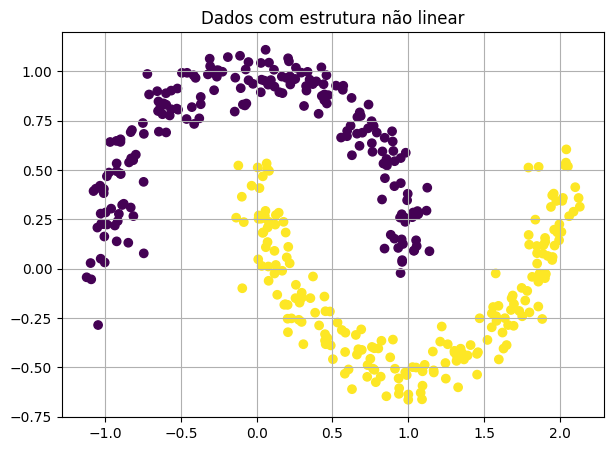

In [11]:
X_moons, y_moons = make_moons(n_samples=400, noise=0.08, random_state=42)

plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons)
plt.title("Dados com estrutura não linear")
plt.show()

Agora vamos adicionar ruído e novas features, criando uma versão com mais dimensões.

In [12]:
noise_features = np.random.randn(X_moons.shape[0], 8)
X_moons_high = np.hstack([X_moons, noise_features])

print("Shape original:", X_moons.shape)
print("Shape com mais features:", X_moons_high.shape)

Shape original: (400, 2)
Shape com mais features: (400, 10)


Temos agora um problema com **10 features**, mas cuja estrutura mais importante continua sendo não linear.

## 12. t-SNE: intuição

O **t-SNE** é uma técnica de redução de dimensionalidade muito usada para **visualização**.

A intuição principal é:

> pontos que eram vizinhos no espaço original devem continuar próximos no mapa 2D final.

Diferentemente do PCA:

- o t-SNE é **não linear**;
- ele costuma preservar melhor a **estrutura local**;
- ele é excelente para explorar agrupamentos visualmente;
- ele não é, em geral, a melhor escolha para compressão ou pré-processamento geral de modelos.

### Ideia intuitiva

O t-SNE tenta montar um “mapa” em 2D dos dados de alta dimensão, de modo que pontos parecidos fiquem perto uns dos outros.

## 13. Primeiro exemplo com t-SNE

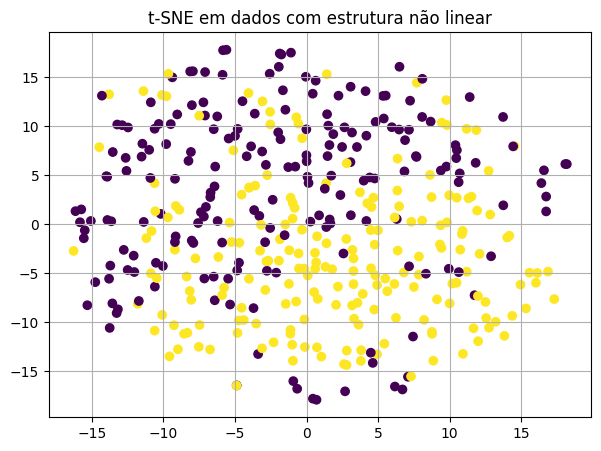

In [13]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca"
)

X_moons_tsne = tsne.fit_transform(X_moons_high)

plt.scatter(X_moons_tsne[:, 0], X_moons_tsne[:, 1], c=y_moons)
plt.title("t-SNE em dados com estrutura não linear")
plt.show()

### Parâmetros importantes do t-SNE

#### `n_components`
Número de dimensões do embedding final.

Na prática introdutória, normalmente usamos:
- `n_components=2` para visualização em 2D.

#### `perplexity`
Um dos hiperparâmetros mais importantes.

De forma intuitiva, ele está relacionado ao tamanho da vizinhança que o algoritmo considera.

Valores comuns:
- entre 5 e 50

Não existe um valor universalmente melhor.  
Vale testar e comparar.

#### `random_state`
Muito importante para reprodutibilidade.

Como o t-SNE pode gerar resultados diferentes em execuções diferentes, definir `random_state` ajuda a reproduzir os gráficos.

#### `init`
Modo de inicialização.
Usar `init="pca"` costuma ser uma boa escolha.

#### `learning_rate`
Afeta a forma como o embedding evolui durante a otimização.

#### `max_iter`
Número de iterações do algoritmo.

## 14. Efeito da perplexity

Uma característica importante do t-SNE é que o resultado visual pode mudar bastante com os hiperparâmetros.

Vamos observar o efeito da `perplexity`.

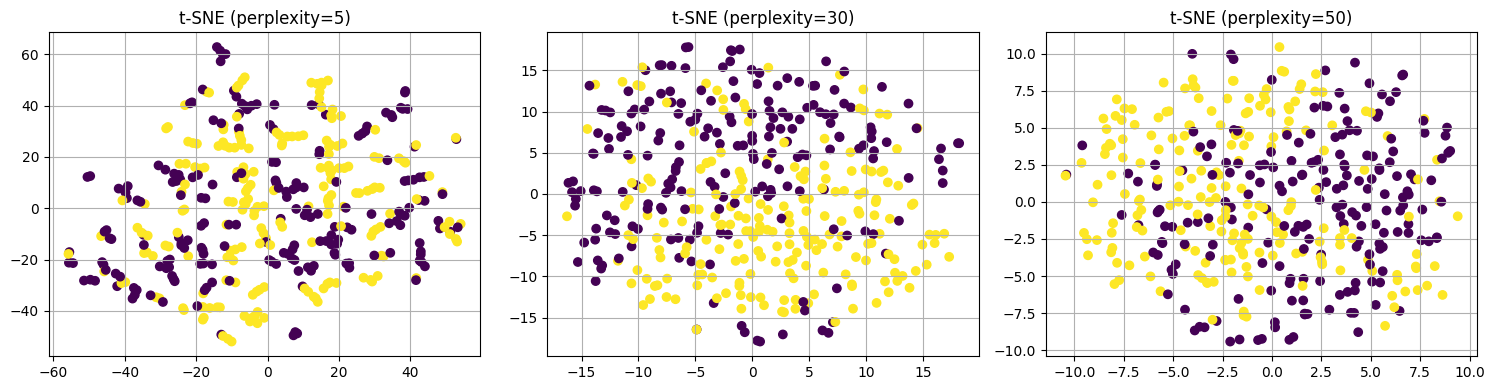

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, perp in zip(axes, [5, 30, 50]):
    tsne = TSNE(
        n_components=2,
        perplexity=perp,
        random_state=42,
        init="pca"
    )
    X_emb = tsne.fit_transform(X_moons_high)
    ax.scatter(X_emb[:, 0], X_emb[:, 1], c=y_moons)
    ax.set_title(f"t-SNE (perplexity={perp})")

plt.tight_layout()
plt.show()

### Interpretação importante

No t-SNE:

- o desenho final pode mudar com os hiperparâmetros;
- a distância global entre grupos nem sempre deve ser interpretada literalmente;
- ele é muito útil para **exploração visual**, mas deve ser usado com cuidado.

## 15. Comparação direta: PCA vs t-SNE

Agora vamos comparar as duas técnicas no mesmo conjunto de dados.

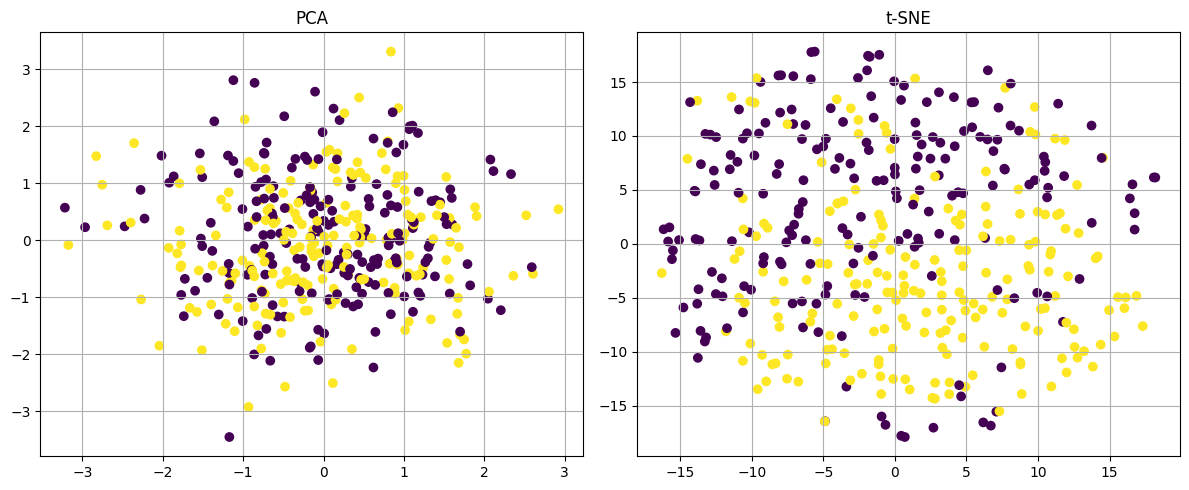

In [15]:
pca_compare = PCA(n_components=2)
X_moons_pca = pca_compare.fit_transform(X_moons_high)

tsne_compare = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca"
)
X_moons_tsne = tsne_compare.fit_transform(X_moons_high)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X_moons_pca[:, 0], X_moons_pca[:, 1], c=y_moons)
axes[0].set_title("PCA")

axes[1].scatter(X_moons_tsne[:, 0], X_moons_tsne[:, 1], c=y_moons)
axes[1].set_title("t-SNE")

plt.tight_layout()
plt.show()

### Diferenças práticas

#### PCA
- linear
- rápido
- simples de interpretar
- útil para compressão e pré-processamento
- tende a preservar melhor a estrutura global de variância

#### t-SNE
- não linear
- mais voltado para visualização
- destaca melhor relações locais
- mais caro computacionalmente
- pode gerar mapas visualmente mais separados

## 16. Exemplo real mais visual: dataset Digits

O dataset Digits contém imagens de dígitos escritos à mão.

Cada imagem tem tamanho **8 x 8**, ou seja:

- 64 pixels por imagem
- logo, 64 features por amostra

Assim, cada dígito pode ser visto como um ponto em **64 dimensões**.

In [16]:
digits = load_digits()
X_digits = digits.data
y_digits = digits.target

print("Shape de X_digits:", X_digits.shape)

Shape de X_digits: (1797, 64)


Vamos visualizar algumas imagens.

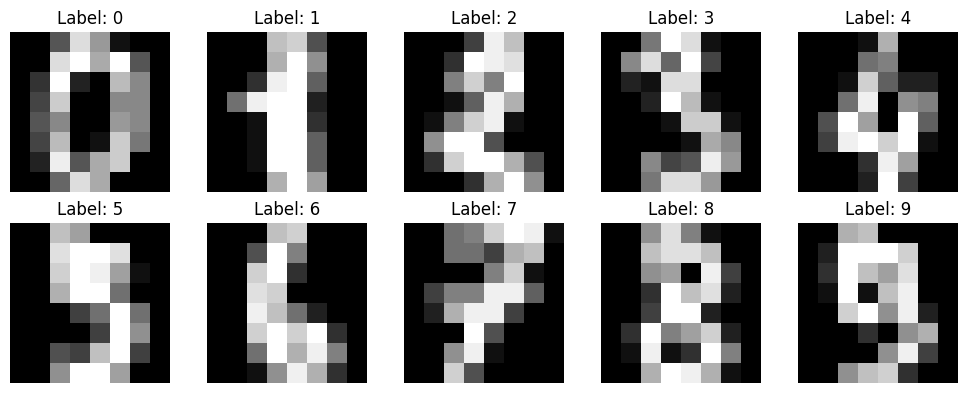

In [17]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for ax, img, label in zip(axes.ravel(), digits.images[:10], y_digits[:10]):
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()

Agora vamos reduzir de 64 dimensões para 2 usando PCA e t-SNE.

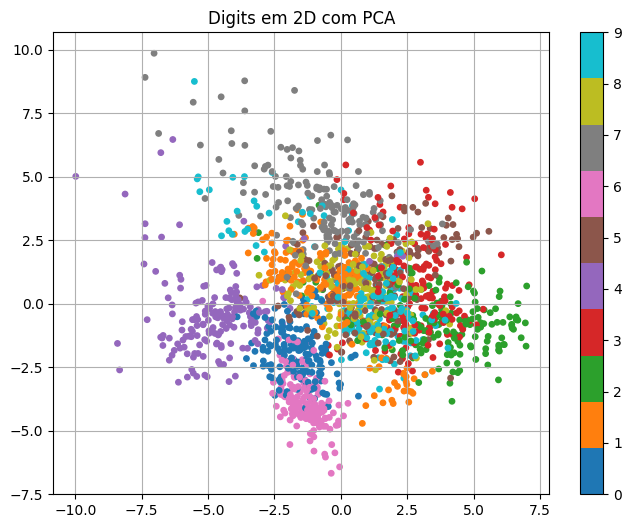

In [18]:
X_digits_scaled = StandardScaler().fit_transform(X_digits)

X_digits_pca = PCA(n_components=2).fit_transform(X_digits_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_digits_pca[:, 0], X_digits_pca[:, 1], c=y_digits, cmap="tab10", s=15)
plt.colorbar(scatter)
plt.title("Digits em 2D com PCA")
plt.show()

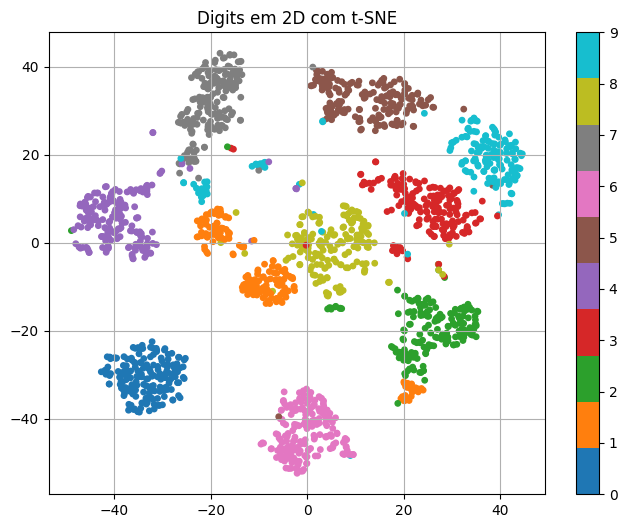

In [19]:
X_digits_tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca"
).fit_transform(X_digits_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_digits_tsne[:, 0], X_digits_tsne[:, 1], c=y_digits, cmap="tab10", s=15)
plt.colorbar(scatter)
plt.title("Digits em 2D com t-SNE")
plt.show()

Em muitos casos, o t-SNE mostra agrupamentos visuais mais claros do que o PCA.

Mas isso não significa automaticamente que ele seja “melhor” em todo sentido.  
O que acontece é que ele foi desenhado justamente para visualização e preservação local.

## 17. Boa prática: PCA antes de t-SNE

Em datasets com muitas dimensões, uma estratégia comum é:

1. aplicar PCA primeiro para reduzir o número de features;
2. depois usar t-SNE sobre essa representação intermediária.

Isso pode:
- acelerar o processo;
- reduzir ruído;
- facilitar a visualização.

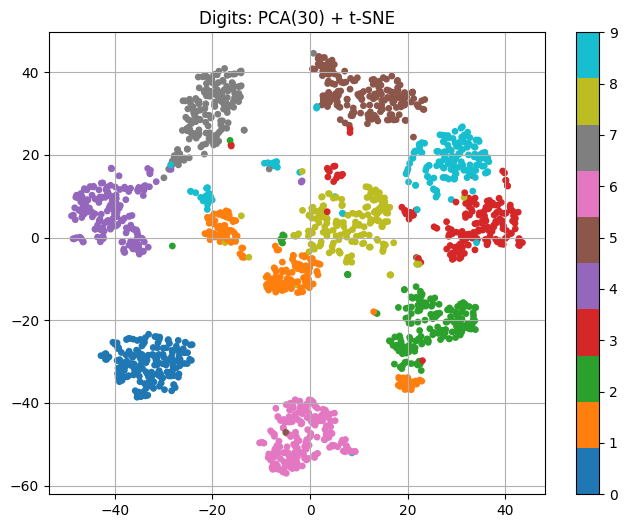

In [20]:
X_digits_pca30 = PCA(n_components=30, random_state=42).fit_transform(X_digits_scaled)

X_digits_tsne_pca = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca"
).fit_transform(X_digits_pca30)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_digits_tsne_pca[:, 0], X_digits_tsne_pca[:, 1], c=y_digits, cmap="tab10", s=15)
plt.colorbar(scatter)
plt.title("Digits: PCA(30) + t-SNE")
plt.show()

## 18. Resumo final

### O que vimos

- a dimensionalidade de um problema está associada ao número de features;
- reduzir dimensionalidade significa criar uma nova representação com menos eixos;
- o **PCA** procura direções que resumem a maior parte da variação dos dados;
- o **t-SNE** tenta preservar vizinhanças locais e é muito útil para visualização.

### Quando usar PCA?
- quando você quer uma técnica simples e rápida;
- quando deseja compressão ou pré-processamento;
- quando quer manter a maior parte da variância em menos dimensões.

### Quando usar t-SNE?
- quando o objetivo principal é visualização;
- quando você quer explorar agrupamentos locais;
- quando suspeita que a estrutura dos dados não é bem representada de forma linear.

### Cuidados
- PCA pode exigir padronização;
- t-SNE depende bastante dos hiperparâmetros;
- o mapa gerado pelo t-SNE deve ser interpretado com cautela.

## 19. Exercícios sugeridos

1. Altere o número de componentes do PCA no Iris para `1`, `2` e `3`. O que muda?
2. Teste diferentes valores de `perplexity` no t-SNE.
3. Rode o t-SNE com diferentes `random_state` e compare.
4. Aplique PCA e t-SNE em outro dataset do `scikit-learn`.
5. Compare os resultados com e sem `StandardScaler`.

## 20. Conclusão

PCA e t-SNE são duas ferramentas muito úteis, mas com propostas diferentes.

O mais importante neste ponto é guardar a intuição:

> redução de dimensionalidade não é apenas “diminuir colunas”, mas tentar construir uma representação mais compacta dos dados, preservando o que é mais relevante para análise e visualização.